# Appendix B

<img src="https://github.com/djp840/MSDS_458_Public/blob/main/images2/NorthwesternHeader.png?raw=1" />

## MSDS458 Research Assignment 1:
Soraya Karimi Butler <br>
01/26/2026


In this notebook, we will
  1. Build a `DNN` model for classifying MNIST digits. The `DNN` model will consist of 784 input nodes, a hidden layer with 128 nodes and 10 output nodes (corresponding to the 10 digits). We use `mnist.load_data()` to get the 70,000 images divided into a set of 60,000 training images and 10,000 test images. We hold back 20% of the 60,000 training images for validation. After training the model, we group the 60,000 activation values of the hidden node for the (original) set of training images by the 10 predicted classes and visualize these sets of values using a boxplot
  2. Build a `DNN` with 784 input nodes, a hidden layer with 2 nodes and 10 output nodes (corresponding to the 10 digits). For each of the 60,000 images, the output of the two hidden nodes are plotted using a scatterplot
  3. Repeat #2 with varying combinations of nodes and layers.
  4. Use PCA decomposition to reduce the number of dimensions of our training set of 28x28 dimensional MNIST images from 784 to 154 (with 95% of training images variance lying along these components). We also reduce the number of dimensions of 'best' model from Experiment 3 to 154 inputs nodes and train it on the new lower dimensional data
  5. Use a Random Forest classifier to get the relative importance of the 784 features (pixels) of the 28x28 dimensional images in training set of MNIST images and select the top 70 features (pixels). We train our 'best' dense neural network using these 70 features and compare its performance to the the dense neural network models from EXPERIMENTS 3 and 4
  



# Importing Packages

* First we import all the packages that will be used in the assignment.

* Since Keras is integrated in TensorFlow 2.x, we import `keras` from `tensorflow` and use `tenserflow.keras.xxx` to import all other Keras packages. The seed argument produces a deterministic sequence of tensors across multiple calls.

In [ ]:
import datetime
from packaging import version
from collections import Counter
import numpy as np
import pandas as pd

import matplotlib as mpl  # EA
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.models import Sequential
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
import tensorflow.keras.backend as k
from tensorflow.keras.layers import Input

import time

In [ ]:
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)

## Verify TensorFlow version

In [ ]:
print("This notebook requires TensorFlow 2.0 or above")
print("TensorFlow version: ", tf.__version__)
assert version.parse(tf.__version__).release[0] >=2

This notebook requires TensorFlow 2.0 or above
TensorFlow version:  2.19.0


In [ ]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


## Mount Google Drive to Colab environment

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Research Assignment Reporting Functions

In [ ]:
def print_validation_report(test_labels, predictions):
    print("Classification Report")
    print(classification_report(test_labels, predictions))
    print('Accuracy Score: {}'.format(accuracy_score(test_labels, predictions)))
    print('Root Mean Square Error: {}'.format(np.sqrt(MSE(test_labels, predictions))))

def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(16,12))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.75,  cbar=False, ax=ax,cmap='Blues',linecolor='white')
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

    return mtx

def plot_history(history):
  losses = history.history['loss']
  accs = history.history['accuracy']
  val_losses = history.history['val_loss']
  val_accs = history.history['val_accuracy']
  epochs = len(losses)

  plt.figure(figsize=(16, 4))
  for i, metrics in enumerate(zip([losses, accs], [val_losses, val_accs], ['Loss', 'Accuracy'])):
    plt.subplot(1, 2, i + 1)
    plt.plot(range(epochs), metrics[0], label='Training {}'.format(metrics[2]))
    plt.plot(range(epochs), metrics[1], label='Validation {}'.format(metrics[2]))
    plt.legend()
  plt.show()

def plot_digits(instances, pos, images_per_row=5, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    pos.imshow(image, cmap = 'binary', **options)
    pos.axis("off")

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = 'hot',
               interpolation="nearest")
    plt.axis("off")

# Loading MNIST Dataset

* The MNIST dataset of handwritten digits has a training set of 60,000 images, and a test set of 10,000 images. It comes prepackaged as part of `tf.Keras`. Use the `tf.keras.datasets.mnist.load_data` to the get these datasets (and the corresponding labels) as Numpy arrays.

In [ ]:
(train_images, train_labels), (test_images, test_labels)= tf.keras.datasets.mnist.load_data()

* Tuples of Numpy arrays: `(x_train, y_train)`, `(x_test, y_test)`
* `x_train`, `x_test`: uint8 arrays of grayscale image data with shapes (num_samples, 28, 28).
* `y_train`, `y_test`: uint8 arrays of digit labels (integers in range 0-9)

## EDA Training and Test Sets

* Inspect the training and test sets as well as their labels as follows.

In [ ]:
print('train_images:\t{}'.format(train_images.shape))
print('train_labels:\t{}'.format(train_labels.shape))
print('test_images:\t\t{}'.format(test_images.shape))
print('test_labels:\t\t{}'.format(test_labels.shape))

train_images:	(60000, 28, 28)
train_labels:	(60000,)
test_images:		(10000, 28, 28)
test_labels:		(10000,)


## Review labels for training set

In [ ]:
print("First ten labels training dataset:\n {}\n".format(test_labels[0:10]))

First ten labels training dataset:
 [7 2 1 0 4 1 4 9 5 9]



## Find frequency of each label in training and test sets

Text(0.5, 1.0, 'Distribution of Training Labels')

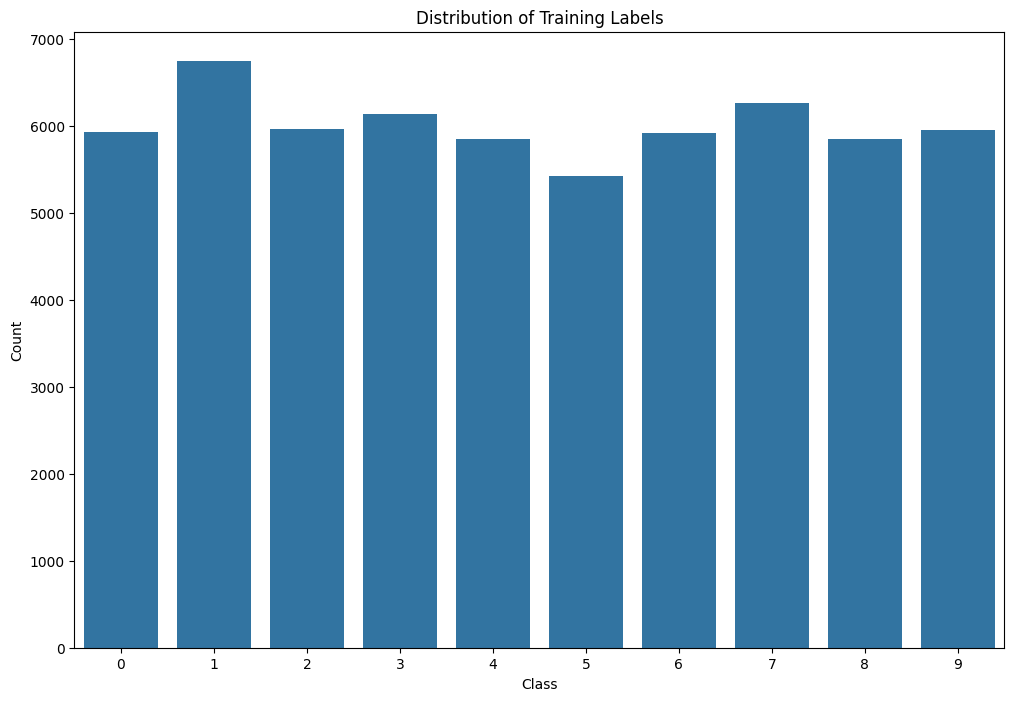

In [ ]:
plt.figure(figsize = (12 ,8))
items = [{'Class': x, 'Count': y} for x, y in Counter(train_labels).items()]
distribution = pd.DataFrame(items).sort_values(['Class'])
sns.barplot(x=distribution.Class, y=distribution.Count);
# set the title
plt.title('Distribution of Training Labels')

In [ ]:
Counter(train_labels).most_common()

[(np.uint8(1), 6742),
 (np.uint8(7), 6265),
 (np.uint8(3), 6131),
 (np.uint8(2), 5958),
 (np.uint8(9), 5949),
 (np.uint8(0), 5923),
 (np.uint8(6), 5918),
 (np.uint8(8), 5851),
 (np.uint8(4), 5842),
 (np.uint8(5), 5421)]

In [ ]:
Counter(test_labels).most_common()

[(np.uint8(1), 1135),
 (np.uint8(2), 1032),
 (np.uint8(7), 1028),
 (np.uint8(3), 1010),
 (np.uint8(9), 1009),
 (np.uint8(4), 982),
 (np.uint8(0), 980),
 (np.uint8(8), 974),
 (np.uint8(6), 958),
 (np.uint8(5), 892)]

## Plot sample images with their labels

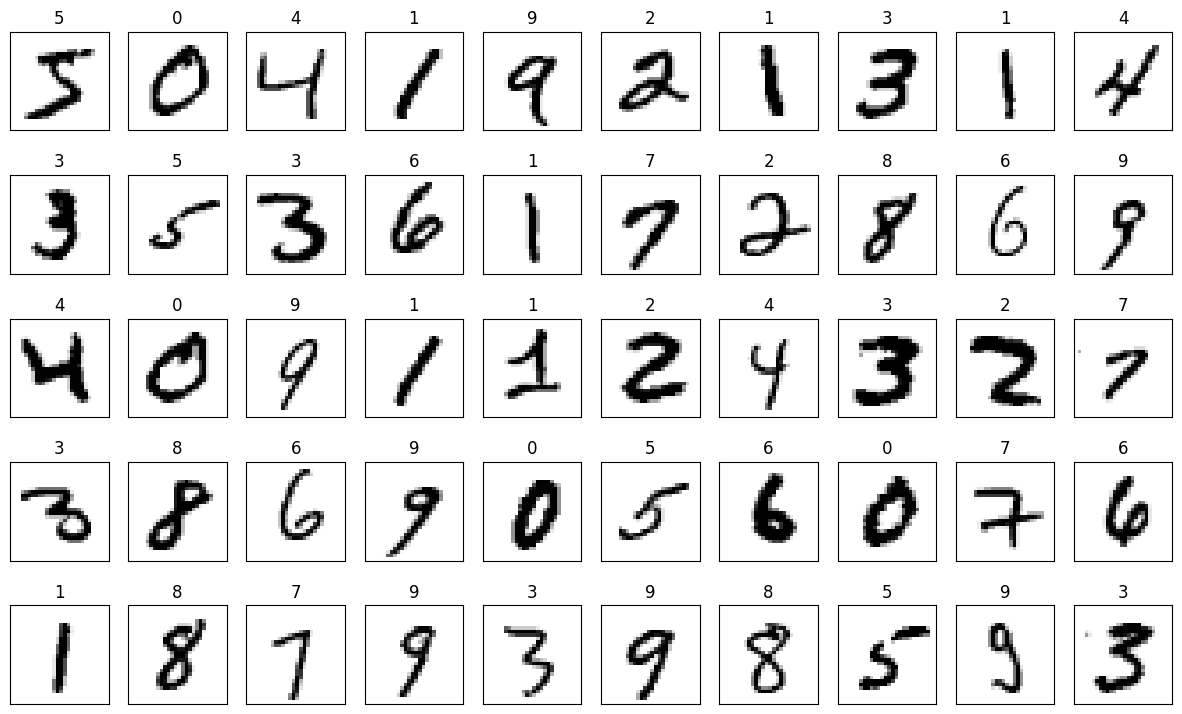

In [ ]:
fig = plt.figure(figsize = (15, 9))

for i in range(50):
    plt.subplot(5, 10, 1+i)
    plt.title(train_labels[i])
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i].reshape(28,28), cmap='binary')

## Reshape the images to 1D arrays

Reshape the images from shape (28, 28) 2D arrays to shape (784, ) vectors (1D arrays).

In [ ]:
# Before reshape:
print('x_train:\t{}'.format(train_images.shape))
print('x_test:\t\t{}'.format(test_images.shape))

x_train:	(60000, 28, 28)
x_test:		(10000, 28, 28)


In [ ]:
np.set_printoptions(linewidth=np.inf)
print("{}".format(train_images[2020]))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 167 208  19   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  13 235 254  99   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  74 254 234   4   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 154 254 145   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 224 254  92   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  51 245 211  13   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   2 169 254 101   0   0   0   0   0   

In [ ]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

1. Each element in an image is a pixel value
2. Pixel values range from 0 to 255
3. 0 = White
4. 255 = Black

In [ ]:
# set apart training and validation sets, to prevent data leakage in validation
val_images, train_images = train_images[:5000], train_images[5000:]
val_labels, train_labels = train_labels[:5000], train_labels[5000:]

# Experiment 1

* Our dense neural network will consist of 784 input nodes, a hidden layer with 1 node and 10 output nodes (corresponding to the 10 digits).
* We hold back 5,000 of the 60,000 training images for validation.
* After training the model, we group the 60,000 activation values of the hidden node for the (original) set of training images by the 10 predicted classes and visualize these sets of values using a boxplot.
* We expect the overlap between the range of values in the "boxes" to be minimal.
* In addition, we find the pattern that maximally activates the hidden node as a "warm up" exercise for similar analysis we will perform on CNN models in Assignment 2

## Build the DNN model

Our dense neural network will consist of 784 input nodes, a hidden layer with 1 node and 10 output nodes (corresponding to the 10 digits).

In [ ]:
k.clear_session()
model = Sequential([
  Dense( input_shape=[784], units=1, activation = tf.nn.relu,kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    Dense(name = "output_layer", units = 10, activation = tf.nn.softmax)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │           785 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805 (3.14 KB)

 Trainable params: 805 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

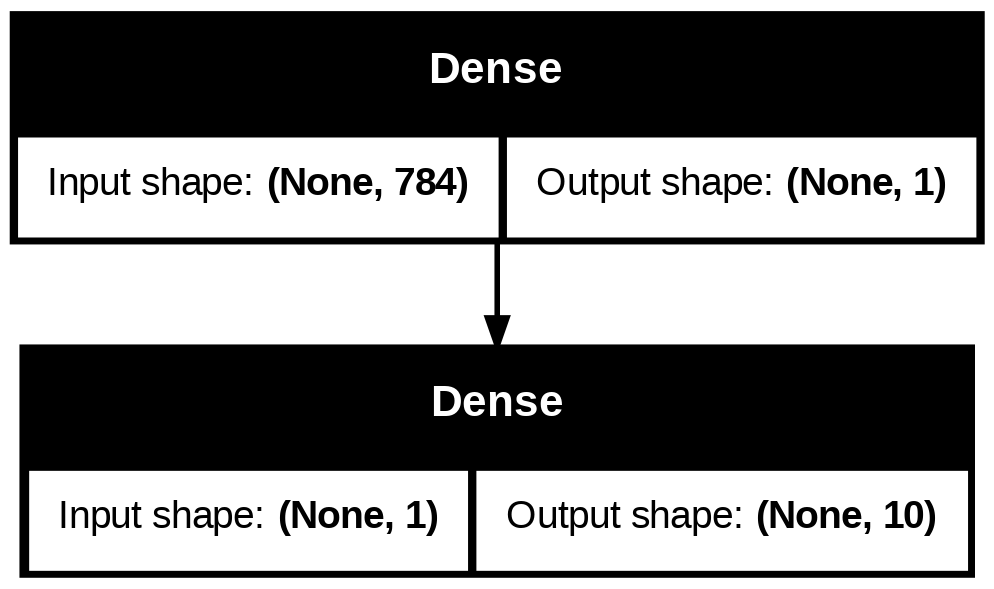

In [ ]:
keras.utils.plot_model(model, "mnist_model.png", show_shapes=True)

## Compile the DNN model


In [ ]:
model.compile(optimizer='rmsprop',
               loss = 'sparse_categorical_crossentropy',
               metrics=['accuracy'])

## Train the DNN model


In [ ]:
history = model.fit(
   train_images
   , train_labels
    ,epochs = 30
    ,validation_data=(val_images, val_labels)

    )

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1877 - loss: 2.0866 - val_accuracy: 0.2360 - val_loss: 1.8700
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2549 - loss: 1.8446 - val_accuracy: 0.2744 - val_loss: 1.7828
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2834 - loss: 1.7714 - val_accuracy: 0.3020 - val_loss: 1.7263
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3013 - loss: 1.7202 - val_accuracy: 0.3178 - val_loss: 1.6811
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3168 - loss: 1.6812 - val_accuracy: 0.3298 - val_loss: 1.6490
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3278 - loss: 1.6551 - val_accuracy: 0.3416 - val_loss: 1.6274
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3333 - loss: 1.6383 - val_accuracy: 0.3436 - val_loss: 1.6122
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3389 - loss: 1.6264 - 

## Evaluate the DNN model


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('test set accuracy: ', test_acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3945 - loss: 1.5629
test set accuracy:  40.139999985694885


## Making Predictions

In [ ]:
preds = model.predict(test_images)
print('shape of preds: ', preds.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
shape of preds:  (10000, 10)


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot performance metrics

We use `Matplotlib` to create 2 plots--displaying the training and validation loss (resp. accuracy) for each (training) epoch side by side.

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)

In [ ]:
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
25,0.395,1.555,0.424,1.549
26,0.396,1.555,0.425,1.548
27,0.396,1.554,0.425,1.547
28,0.397,1.553,0.424,1.547
29,0.397,1.553,0.426,1.546


In [ ]:
def display_training_curves(training, validation, title, subplot):
  ax = plt.subplot(subplot)
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['training', 'validation'])

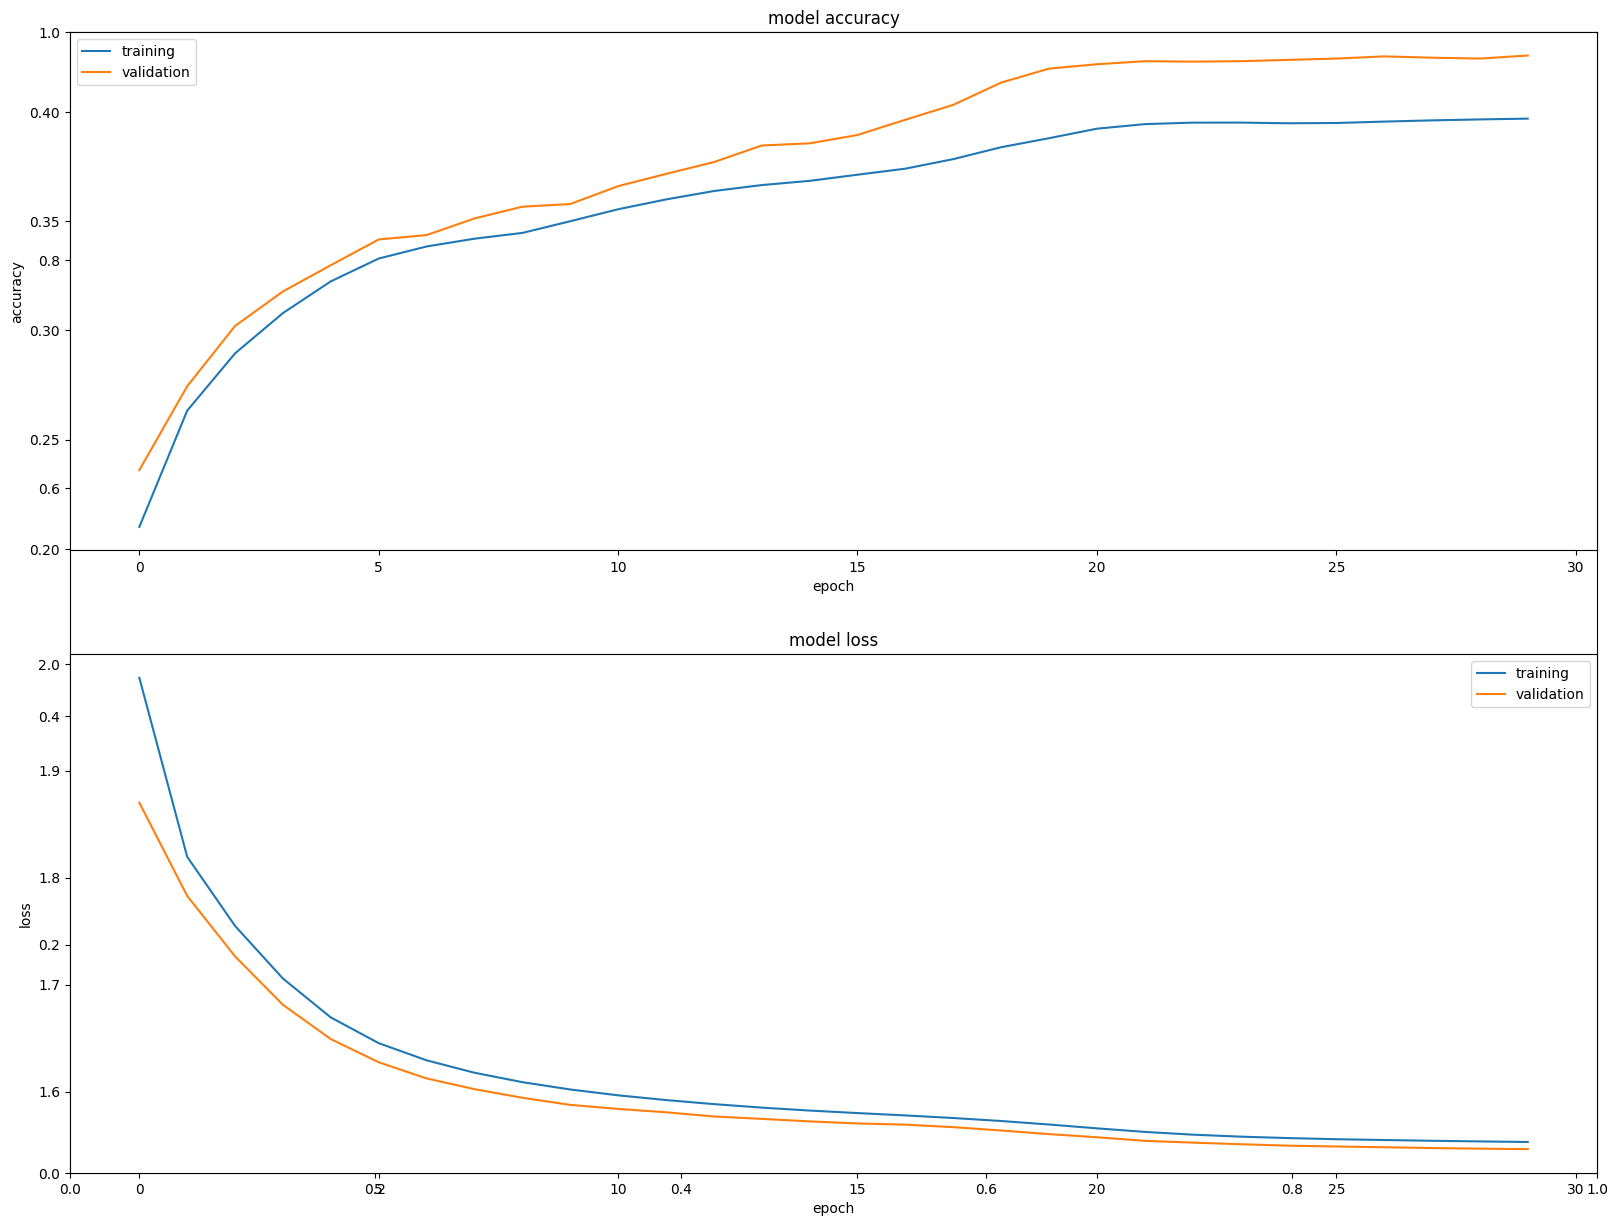

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
pred1= model.predict(test_images)
pred1=np.argmax(pred1, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


## Create the confusion matrix


In [ ]:
# Get the predicted classes:
pred_classes = np.argmax(model.predict(test_images), axis=-1)
pred_classes;

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
conf_mx = tf.math.confusion_matrix(test_labels, pred_classes)
conf_mx;

In [ ]:
cm = sns.light_palette((260, 75, 60), input="husl", as_cmap=True)
df = pd.DataFrame(preds[0:20], columns = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
df.style.format("{:.2%}").background_gradient(cmap=cm)

,0,1,2,3,4,5,6,7,8,9
0,0.02%,4.63%,1.80%,5.87%,17.63%,1.77%,0.12%,33.82%,5.36%,29.00%
1,49.30%,0.00%,6.23%,1.25%,0.02%,5.01%,37.14%,0.00%,1.04%,0.00%
2,0.00%,74.74%,0.05%,0.26%,1.90%,0.05%,0.00%,15.91%,0.24%,6.86%
3,49.31%,0.00%,6.23%,1.25%,0.02%,5.01%,37.14%,0.00%,1.04%,0.00%
4,0.08%,0.38%,4.92%,12.26%,22.57%,4.73%,0.49%,19.33%,11.09%,24.14%
5,0.00%,85.83%,0.02%,0.10%,0.86%,0.02%,0.00%,9.49%,0.09%,3.60%
6,0.11%,0.21%,5.92%,13.85%,22.79%,5.66%,0.65%,16.22%,12.50%,22.08%
7,0.01%,14.18%,0.89%,3.35%,12.98%,0.89%,0.05%,37.88%,3.07%,26.71%
8,1.63%,0.00%,18.00%,22.23%,11.36%,16.46%,5.58%,1.18%,19.63%,3.94%
9,0.02%,3.69%,2.02%,6.42%,18.37%,1.98%,0.14%,32.55%,5.85%,28.97%


## Visualize the confusion matrix

Text(0.5, 1.0, 'Confusion Matrix, Experiment 1 Test Predictions')

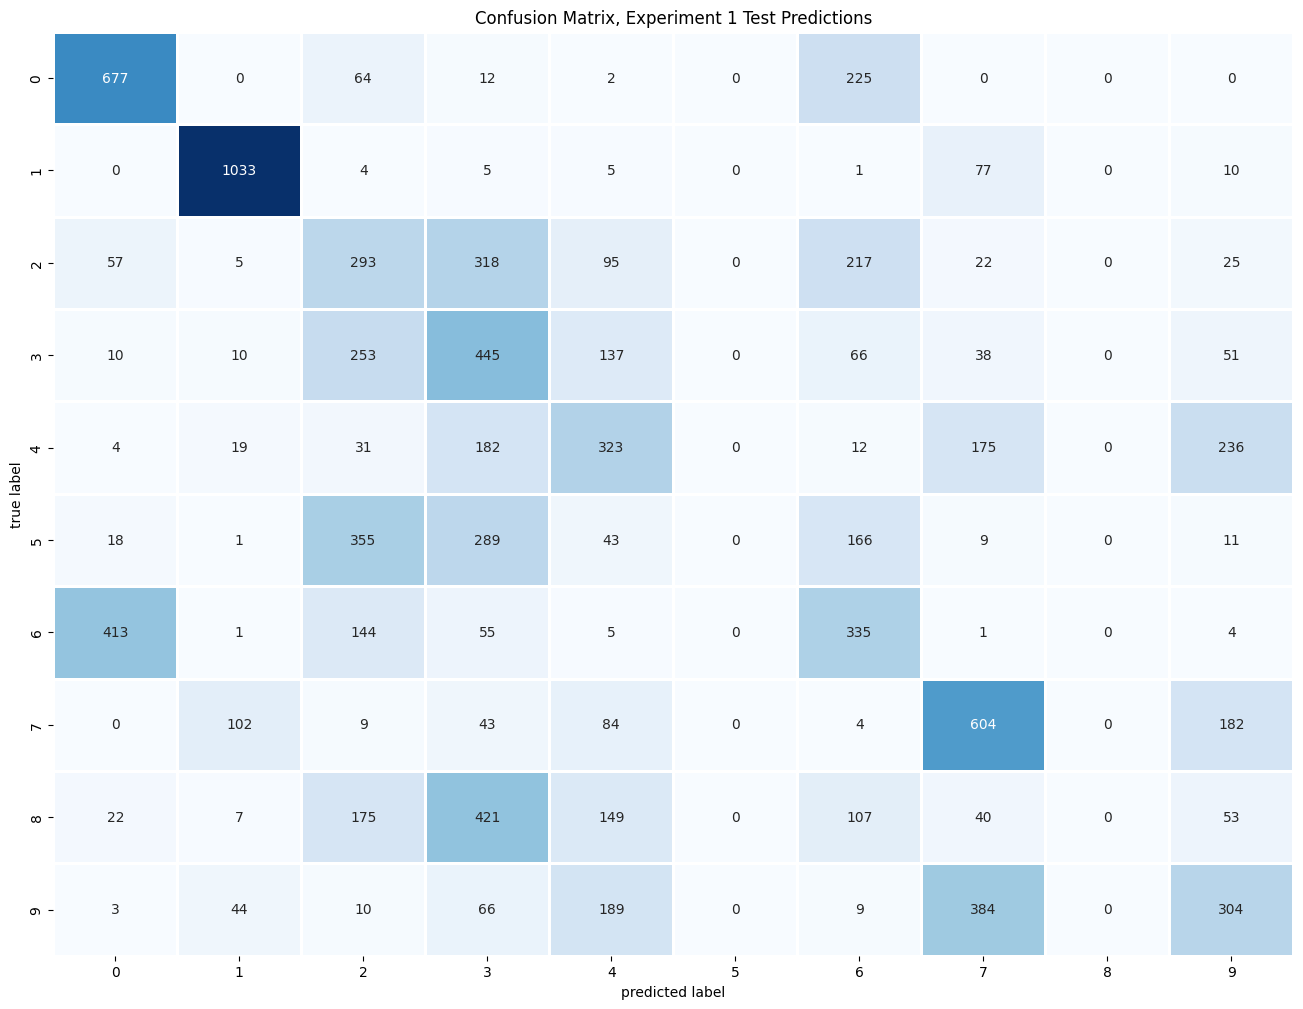

In [ ]:
mtx = plot_confusion_matrix(test_labels,pred_classes)
# set the title
plt.title('Confusion Matrix, Experiment 1 Test Predictions')

 ## Get Activation Values of the Hidden Node

To get the activation values of the hidden nodes, we need to create a new model, `activation_model`, that takes the same input as our current model but outputs the activation value of the hidden layer, i.e. of the hidden node. Then use the `predict` function to get the activation values.

In [ ]:
# Extracts the outputs of the 2 layers:
layer_outputs = [layer.output for layer in model.layers]

# Creates a model that will return these outputs, given the model input:
activation_model = models.Model(inputs=model.inputs, outputs=layer_outputs)

print(f"There are {len(layer_outputs)} layers")
layer_outputs; # description of the layers

There are 2 layers


In [ ]:
# Get the outputs of all the hidden nodes for each of the 60000 training images
activations = activation_model.predict(train_images)
hidden_layer_activation = activations[0]
output_layer_activations = activations[1]
hidden_layer_activation.shape   #  each of the 128 hidden nodes has one activation value per training image

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


(55000, 1)

In [ ]:
output_layer_activations.shape

(55000, 10)

In [ ]:
print(f"The maximum activation value of the hidden nodes in the hidden layer is \
{hidden_layer_activation.max()}")

The maximum activation value of the hidden nodes in the hidden layer is 12.65655517578125


In [ ]:
# Some stats about the output layer as an aside...
np.set_printoptions(suppress = True)  # display probabilities as decimals and NOT in scientific notation
ouput_layer_activation = activations[1]
print(f"The output node has shape {ouput_layer_activation.shape}")
print(f"The output for the first image are {ouput_layer_activation[0].round(4)}")
print(f"The sum of the probabilities is (approximately) {ouput_layer_activation[0].sum()}")

The output node has shape (55000, 10)
The output for the first image are [0.001 0.005 0.047 0.118 0.224 0.045 0.004 0.203 0.107 0.247]
The sum of the probabilities is (approximately) 0.9999999403953552


 ## Create a dataframe with the activation values and the class labels

In [ ]:
#Get the dataframe of all the node values
activation_data = {'actual_class':train_labels}
for k in range(0,1):
    activation_data[f"act_val_{k}"] = hidden_layer_activation[:,k]

activation_df = pd.DataFrame(activation_data)
activation_df.head(15).round(3).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
actual_class,7.000,3.000,4.000,6.00,1.0,8.000,1.000,0.000,9.000,8.000,0.000,3.000,1.0,2.000,7.000
act_val_0,1.567,3.111,1.677,5.18,0.0,3.764,0.015,7.128,1.525,4.465,6.169,3.931,0.0,4.718,0.773


## Displaying The Range Of Activation Values For Each Class Labels

In [ ]:
activation_df.groupby("actual_class")["act_val_0"].apply(lambda x: [round(min(x.tolist()),2),
 round(max(x.tolist()),2)]).reset_index().rename(columns={"act_val_0": "range_of_act_values"})

,actual_class,range_of_act_values
0,0,"[0.99, 12.66]"
1,1,"[0.0, 5.53]"
2,2,"[0.0, 9.39]"
3,3,"[0.0, 7.58]"
4,4,"[0.0, 7.15]"
5,5,"[0.0, 8.09]"
6,6,"[0.01, 10.53]"
7,7,"[0.0, 7.93]"
8,8,"[0.0, 8.91]"
9,9,"[0.0, 8.78]"


In [ ]:
activation_df

,actual_class,act_val_0
0,7,1.566670
1,3,3.110753
2,4,1.676977
3,6,5.179715
4,1,0.000000
...,...,...
54995,8,2.682629
54996,3,3.305243
54997,5,2.894958
54998,6,5.515946


## Visualize the activation values with boxplots

We get the activation values of the first hidden node and combine them with the corresponding class labels into a DataFrame. We use both `matplotlib` and `seaborn` to create boxplots from the dataframe.

/tmp/ipython-input-2334116201.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bplot = sns.boxplot(y=act_val, x='actual_class',


Text(0.5, 1.0, 'Activation Values of the Hidden Node')

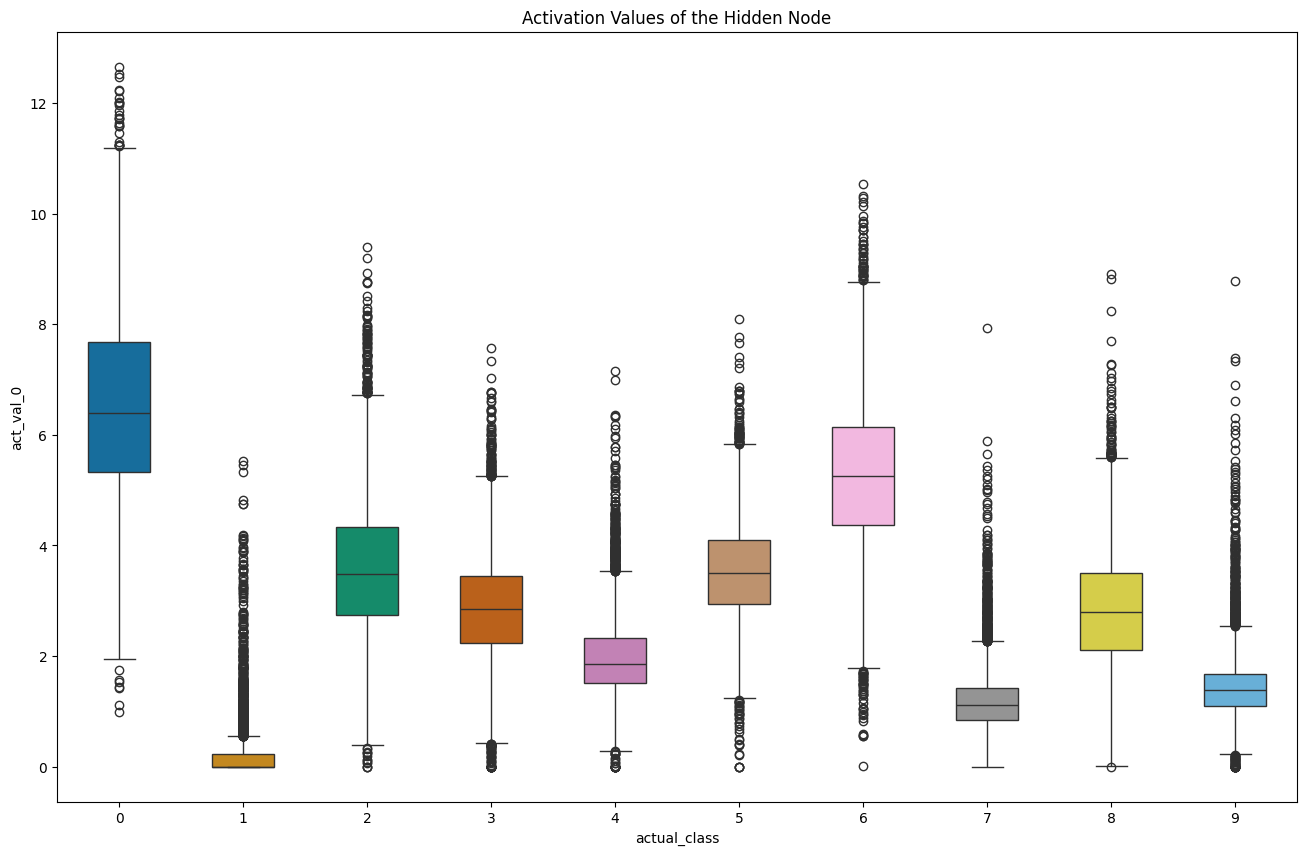

In [ ]:
# To see how closely the hidden node activation values correlate with the class labels
act_val = 'act_val_0'
plt.figure(figsize=(16,10))
bplot = sns.boxplot(y=act_val, x='actual_class',
                 data=activation_df[[act_val,'actual_class']],
                 width=0.5,
                 palette="colorblind")
# set title
plt.title('Activation Values of the Hidden Node')

## Find the pattern that maximally activates the hidden node
as a "warm up" exercise for similar analysis we will perform on CNN models in Assignment 2.<br>
This is a process known as Gradient Ascent. Finding a pattern the hidden node maximally responds toWe adapt the code from https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/5.4-visualizing-what-convnets-learn.ipynb

In [ ]:
def deprocess_image(x):
    # normalize tensor: center on 0., ensure std is 0.1
    x -= x.mean()
    x /= (x.std() + 1e-5)
    x *= 0.1

    # clip to [0, 1]
    x += 0.5
    x = np.clip(x, 0, 1)

    # convert to RGB array
    x *= 255
    x = np.clip(x, 0, 255).astype('uint8')
    return x

In [ ]:
def generate_pattern(layer_name, size=28):
    # Get the output of the layer we want to visualize
    layer_output = model.get_layer(layer_name).output

    # Create a sub-model that maps input to the activation of the target layer
    activation_model = tf.keras.Model(inputs=model.inputs, outputs=layer_output)

    # Start from a random gray image
    input_img_data = tf.random.uniform((1, size * size), minval=0, maxval=1) * 20 + 128.
    input_img_data = tf.Variable(input_img_data)

    optimizer = tf.keras.optimizers.SGD(learning_rate=1.)

    for i in range(1000):
        with tf.GradientTape() as tape:
            # Forward pass
            activations = activation_model(input_img_data)
            # Loss is the mean activation of the layer
            loss = tf.reduce_mean(activations)

        # Compute gradients
        grads = tape.gradient(loss, input_img_data)

        # Normalize gradients
        grads /= (tf.sqrt(tf.reduce_mean(tf.square(grads))) + 1e-5)

        # Gradient ascent
        optimizer.apply_gradients([(grads, input_img_data)])

    img = input_img_data.numpy()[0]
    return deprocess_image(img)

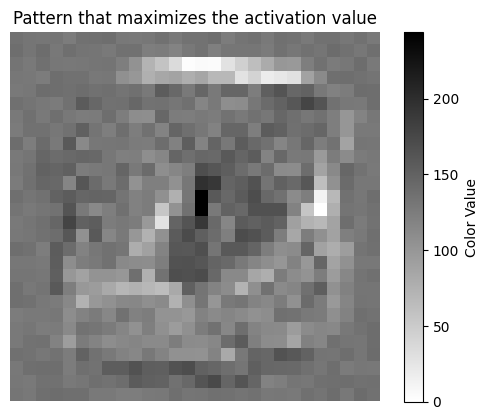

In [ ]:
# Find and display the pattern that maximizes the activation value
max_img = generate_pattern('dense')
scatter = plt.imshow(max_img.reshape(28,28), cmap="binary")

# Add a colorbar to the plot
cbar = plt.colorbar(scatter)
cbar.set_label('Color Value') # Add a label to the colorbar

plt.axis('off')
plt.title('Pattern that maximizes the activation value')
plt.show()

In [ ]:
# print activation value for max_img
max_img_act_value = activation_model.predict(max_img.reshape(-1,784))[0].item(0)
max_img_class = activation_model.predict(max_img.reshape(-1,784))[1].argmax()
print(f"The activation value for max_img is {max_img_act_value}.")
print(f"The model thinks this is an image of a {max_img_class}.")   # check this!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
The activation value for max_img is 316.54168701171875.
The model thinks this is an image of a 0.


# Experiment 2
* This time our dense neural network will have 784 input nodes, a hidden layer with 2 nodes and 10 output nodes (corresponding to the 10 digits).
* For each of the 60,000 images, the output of the two hidden nodes are plotted using a scatterplot.
* We color code the points according to which of the 10 classes the the output of the two nodes predicts.
* Ideally, just like in EXPERIMENT 1, the color clusters should have very little overlap.
* Also compare the accuracy % & confusion matrix of Experiments 1 & 2. Again, the goal is to get more insights.

## Build the DNN Model

In [ ]:
tf.keras.backend.clear_session()
model = models.Sequential()
model.add(layers.Dense(units=2, activation='relu', input_shape=(28 * 28,)))
model.add(layers.Dense(name = "output_layer", units=10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │         1,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,600 (6.25 KB)

 Trainable params: 1,600 (6.25 KB)

 Non-trainable params: 0 (0.00 B)

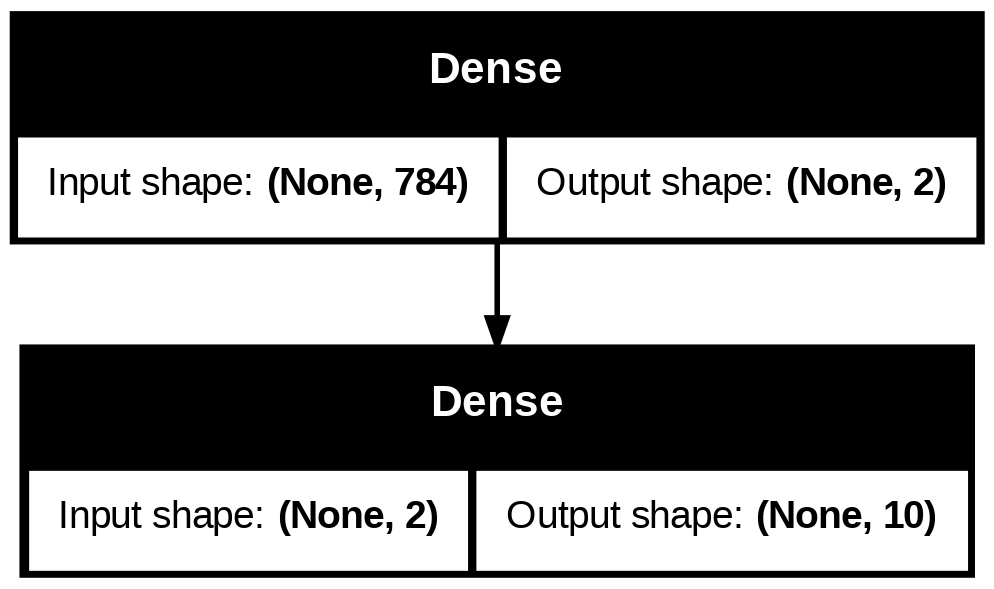

In [ ]:
keras.utils.plot_model(model, "mnist_model.png", show_shapes=True)

## Compile the DNN model


In [ ]:
model.compile(optimizer='rmsprop',
             loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

## Train the DNN model


In [ ]:
history = model.fit(
   train_images
   , train_labels
    ,epochs = 30
    ,validation_data=(val_images, val_labels)
    )

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2614 - loss: 1.9605 - val_accuracy: 0.4866 - val_loss: 1.4377
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5166 - loss: 1.3722 - val_accuracy: 0.5868 - val_loss: 1.2013
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5924 - loss: 1.1956 - val_accuracy: 0.6140 - val_loss: 1.1374
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6165 - loss: 1.1415 - val_accuracy: 0.6352 - val_loss: 1.1033
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6340 - loss: 1.1057 - val_accuracy: 0.6494 - val_loss: 1.0775
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6489 - loss: 1.0808 - val_accuracy: 0.6580 - val_loss: 1.0612
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6559 - loss: 1.0651 - val_accuracy: 0.6654 - val_loss: 1.0510
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6605 - loss: 1.0542 - 

## Evaluate the DNN model


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'test acc: {test_acc}, test loss: {test_loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6621 - loss: 1.0978
test acc: 0.6859999895095825, test loss: 1.0271947383880615


## Making Predictions

In [ ]:
preds = model.predict(test_images)
print('shape of preds: ', preds.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
shape of preds:  (10000, 10)


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Plot performance metrics

We use `Matplotlib` to create 2 plots--displaying the training and validation loss (resp. accuracy) for each (training) epoch side by side.

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
losses = history.history['loss']
accs = history.history['accuracy']
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
epochs = len(losses)

In [ ]:
history_df=pd.DataFrame(history_dict)
history_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
25,0.683,1.016,0.684,1.021
26,0.683,1.015,0.684,1.021
27,0.683,1.015,0.684,1.020
28,0.683,1.014,0.685,1.020
29,0.684,1.014,0.685,1.020


In [ ]:
def display_training_curves(training, validation, title, subplot):
  ax = plt.subplot(subplot)
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['training', 'validation'])

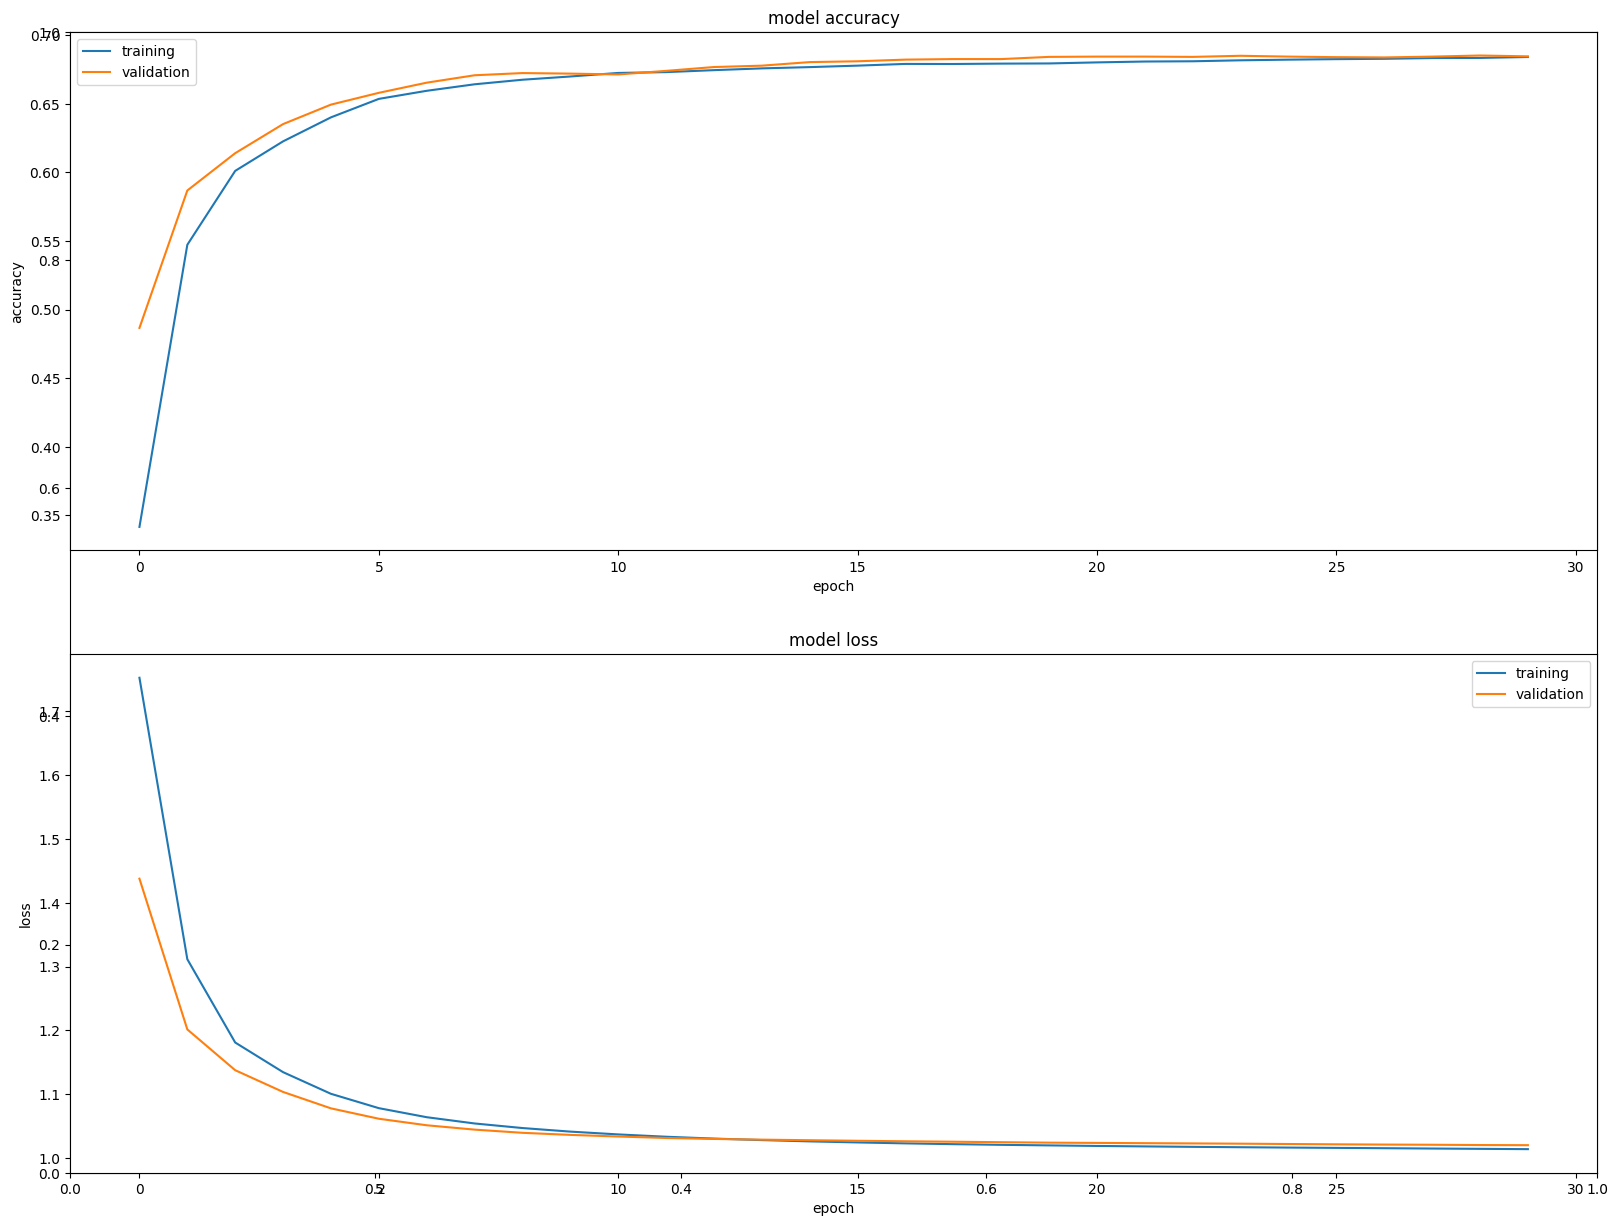

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

In [ ]:
pred1= model.predict(test_images)
pred1=np.argmax(pred1, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
print_validation_report(test_labels, pred1)

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.83      0.75       980
           1       0.77      0.92      0.84      1135
           2       0.83      0.66      0.73      1032
           3       0.63      0.72      0.67      1010
           4       0.70      0.73      0.72       982
           5       0.44      0.40      0.42       892
           6       0.88      0.81      0.84       958
           7       0.74      0.63      0.68      1028
           8       0.47      0.40      0.43       974
           9       0.66      0.70      0.68      1009

    accuracy                           0.69     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.69      0.69      0.68     10000

Accuracy Score: 0.686
Root Mean Square Error: 2.255437873229941


## Create the confusion matrix


In [ ]:
# Get the predicted classes:
pred_probs = model.predict(test_images)
pred_classes = np.argmax(pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
conf_mx = tf.math.confusion_matrix(test_labels, pred_classes)
conf_mx;

In [ ]:
cm = sns.light_palette((260, 75, 60), input="husl", as_cmap=True)
df = pd.DataFrame(preds[0:20], columns = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
df.style.format("{:.2%}").background_gradient(cmap=cm)

,0,1,2,3,4,5,6,7,8,9
0,0.00%,0.00%,0.00%,0.74%,0.00%,0.00%,0.00%,98.02%,0.00%,1.23%
1,0.00%,0.28%,99.72%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
2,7.16%,64.41%,6.62%,1.59%,0.00%,3.88%,8.61%,0.05%,7.66%,0.01%
3,84.08%,1.01%,0.01%,0.01%,4.81%,2.08%,7.03%,0.02%,0.69%,0.27%
4,2.81%,0.06%,0.00%,0.04%,75.18%,8.34%,0.00%,0.50%,1.98%,11.09%
5,1.70%,66.00%,14.61%,3.64%,0.00%,3.25%,1.82%,0.06%,8.91%,0.00%
6,0.02%,0.00%,0.00%,0.08%,52.37%,6.97%,0.00%,2.72%,1.66%,36.19%
7,0.00%,0.00%,0.00%,0.42%,18.50%,9.75%,0.00%,12.12%,3.07%,56.14%
8,50.29%,0.52%,0.00%,0.02%,38.23%,6.19%,0.51%,0.11%,1.64%,2.49%
9,0.00%,0.00%,0.00%,0.03%,0.19%,0.05%,0.00%,36.07%,0.01%,63.64%


## Visualize the confusion matrix


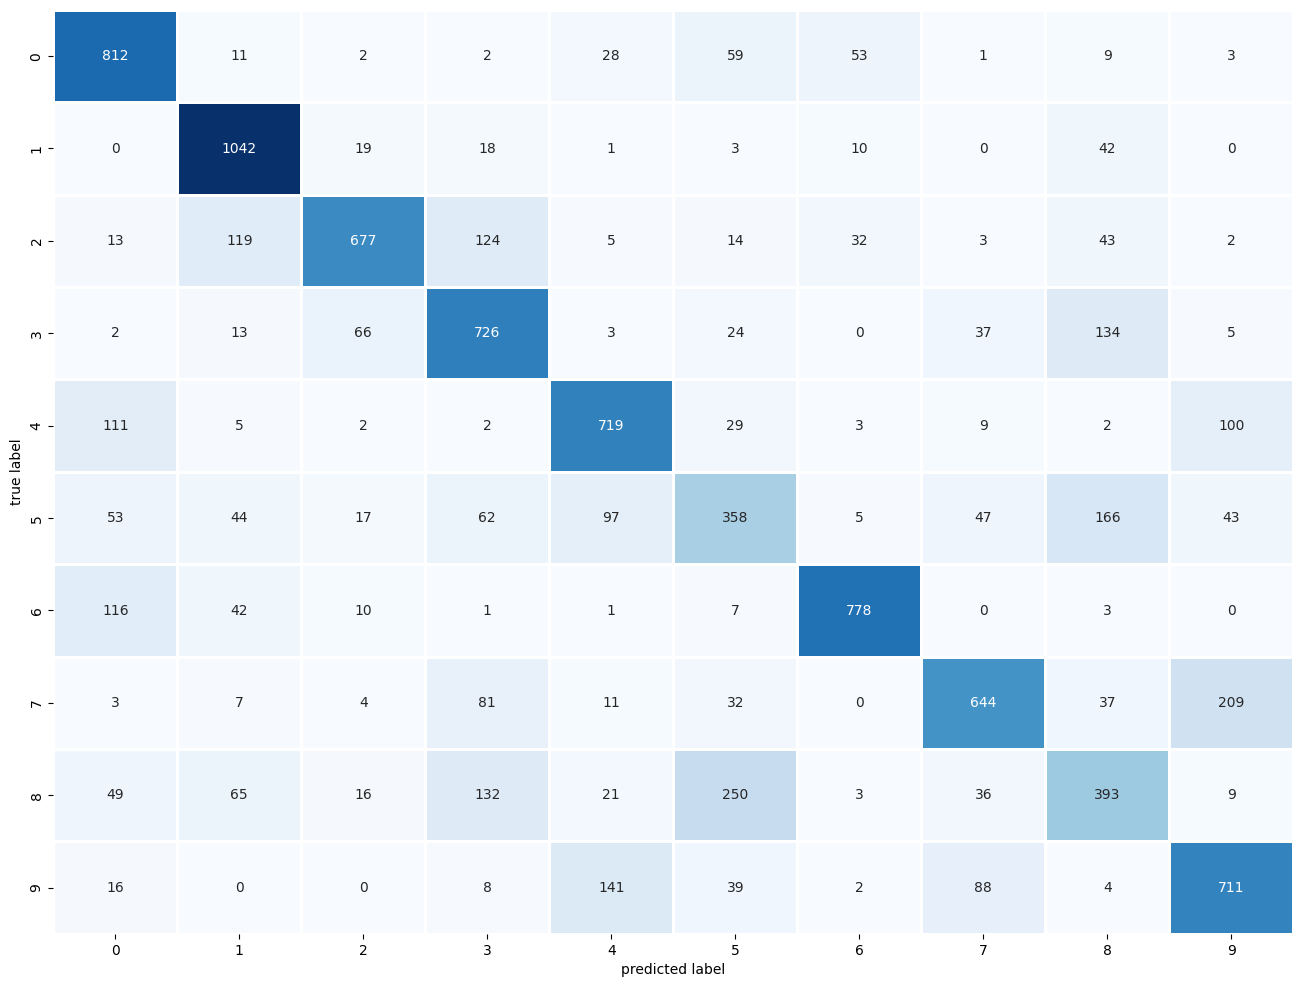

In [ ]:
mtx = plot_confusion_matrix(test_labels,pred_classes)

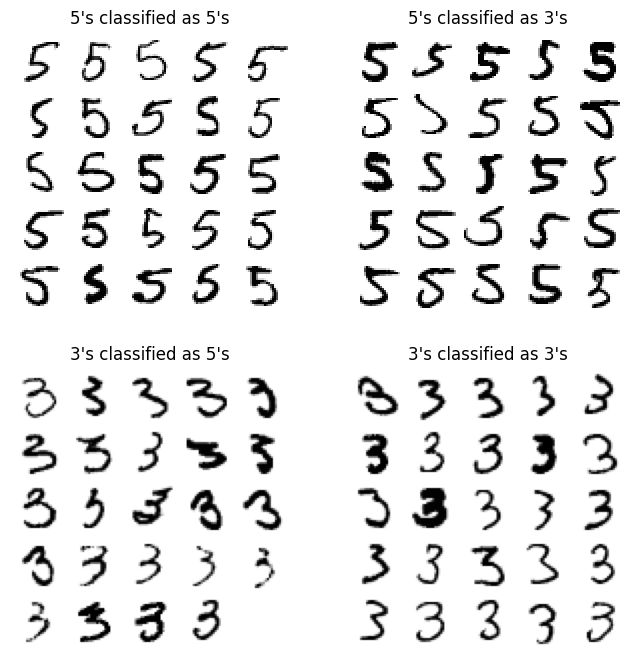

In [ ]:
cl_a, cl_b = 5,3
X_aa = test_images[(test_labels == cl_a) & (pred_classes == cl_a)]
X_ab = test_images[(test_labels == cl_a) & (pred_classes == cl_b)]
X_ba = test_images[(test_labels == cl_b) & (pred_classes == cl_a)]
X_bb = test_images[(test_labels == cl_b) & (pred_classes == cl_b)]

plt.figure(figsize=(8,8))

p1 = plt.subplot(221)
p2 = plt.subplot(222)
p3 = plt.subplot(223)
p4 = plt.subplot(224)

plot_digits(X_aa[:25], p1, images_per_row=5);
plot_digits(X_ab[:25], p2, images_per_row=5);
plot_digits(X_ba[:25], p3, images_per_row=5);
plot_digits(X_bb[:25], p4, images_per_row=5);


p1.set_title(f"{cl_a}'s classified as {cl_a}'s")
p2.set_title(f"{cl_a}'s classified as {cl_b}'s")
p3.set_title(f"{cl_b}'s classified as {cl_a}'s")
p4.set_title(f"{cl_b}'s classified as {cl_b}'s")

plt.show()



## Getting the activation values of the hidden nodes
To get the activation values of the hidden nodes, we need to create a new model, activation_model, that takes the same input as our current model but outputs the activation value of the hidden layer, i.e. of the hidden node. Then use the predict function to get the activation values.

In [ ]:
# Extracts the outputs of the 2 layers:
layer_outputs = [layer.output for layer in model.layers]

# Creates a model that will return these outputs, given the model input:
activation_model = models.Model(inputs=model.inputs, outputs=layer_outputs)

print(f"There are {len(layer_outputs)} layers")
layer_outputs # description of the layers

There are 2 layers


[<KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>,
 <KerasTensor shape=(None, 10), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>]

In [ ]:
activation_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │      1,570 │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 10)        │         30 │ dense[1][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,600 (6.25 KB)

 Trainable params: 1,600 (6.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Get the output of the hidden node for each of the training images
activations = activation_model.predict(train_images)
hidden_layer_activation = activations[0]
hidden_layer_activation.shape   #  2 hidden node each has one activation value per training image

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


(55000, 2)

In [ ]:
hidden_node1_activation = hidden_layer_activation[:,0] # get activation values of the first hidden node
hidden_node2_activation = hidden_layer_activation[:,1] # get activation values of the second hidden node

print(f"The maximum activation value of the first hidden node is {hidden_node1_activation.max()}")
print(f"The maximum activation value of the second hidden node is {hidden_node2_activation.max()}")

The maximum activation value of the first hidden node is 46.41387176513672
The maximum activation value of the second hidden node is 62.915794372558594


In [ ]:
# Some stats about the output layer as an aside...
np.set_printoptions(suppress = True)  # display probabilities as decimals and NOT in scientific notation
ouput_layer_activation = activations[1]
print(f"The output node has shape {ouput_layer_activation.shape}")
print(f"The output for the first image are {ouput_layer_activation[0].round(4)}")
print(f"The sum of the probabilities is (approximately) {ouput_layer_activation[0].sum()}")

The output node has shape (55000, 10)
The output for the first image are [0.    0.    0.    0.168 0.    0.    0.    0.832 0.    0.   ]
The sum of the probabilities is (approximately) 1.0000001192092896


## Creating the scatterplots
<br>
We combine the activation values of the two hidden nodes together with the corresponding predicted classes into a DataFrame. We use both matplotlib and seaborn to create boxplots from the DataFrame.

In [ ]:
train_pred_probs = model.predict(train_images)
train_pred_classes = np.argmax(train_pred_probs, axis=1)
len(train_pred_classes)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


55000

In [ ]:
scatterPlot_df =  pd.DataFrame({'act_value_h1':hidden_node1_activation,
                                'act_value_h2':hidden_node2_activation,
                              'pred_class':train_pred_classes}
)
scatterPlot_df.head()

,act_value_h1,act_value_h2,pred_class
0,21.672567,8.198215,7
1,7.697326,8.112716,3
2,7.602774,0.000000,9
3,0.000000,4.937354,6
4,1.481368,7.498897,1


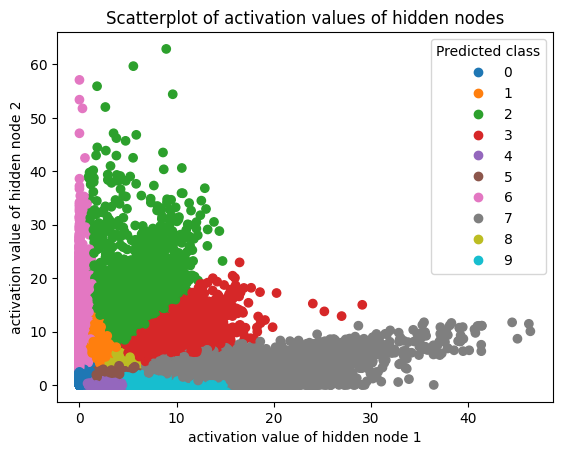

In [ ]:
scatter = plt.scatter(
    scatterPlot_df.act_value_h1,
    scatterPlot_df.act_value_h2,
    c=scatterPlot_df.pred_class,
    cmap='tab10'
)

plt.ylabel('activation value of hidden node 2')
plt.xlabel('activation value of hidden node 1')
plt.title('Scatterplot of activation values of hidden nodes')

legend1 = plt.legend(
    *scatter.legend_elements(),
    title="Predicted class"
)

plt.show()


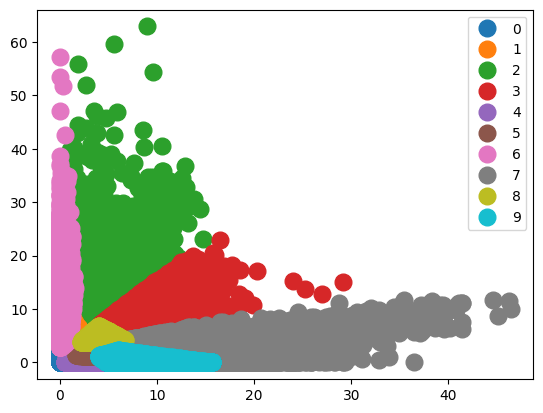

In [ ]:
groups = scatterPlot_df.groupby('pred_class')

# Plot
fig, ax = plt.subplots()
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
for name, group in groups:
    ax.plot(group.act_value_h1, group.act_value_h2, marker='o', linestyle='', ms=12, label=name)
ax.legend()

plt.show()

# Experiment 3
Attempting multiple experiments to find the "best" model

## Functions for efficient experimentation



In [ ]:
 # Model builder function
 # Takes number nodes required
 # for benchmarking and returns model
def build_model( num_nodes,
               num_layers=1,
                num_shape=784,
                num_classes=10
               ):
    model = Sequential()
    model.add(Input(shape=(num_shape,)))
    for _ in range(num_layers):
        model.add(Dense(units=num_nodes, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    # compile
    model.compile(optimizer='rmsprop',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# will return not only metrics but all objects
# needed for further analysis and validation
def return_required_metrics(X_train_nn,
                            y_train_cat,
                            X_test_nn,
                            y_test_cat,
                            val_images,
                            val_labels,
                            num_nodes,
                            num_layers=1
                           ):
  model = build_model(num_layers=num_layers,
                      num_nodes=num_nodes
                     )

  # timing our fit
  start_time = time.time()
  fit_results = model.fit(X_train_nn,
                          y_train_cat,
                          epochs=30,
                          verbose=0,
                          validation_data=(val_images, val_labels))

  training_time = time.time() - start_time
  print("Training time elapsed for num_layers=",
        num_layers,
        ", num_nodes=",
        num_nodes,
        ":",
        training_time
       )


  # obtain metrics
  test_loss, test_acc = model.evaluate(X_test_nn, y_test_cat, verbose=0)

  return_dictionary = {
            'Layers': num_layers,
            'Nodes': num_nodes,
            'Time': round(training_time, 2),
            'Training Accuracy': round(fit_results.history['accuracy'][-1], 3),
            'Testing Accuracy': round(test_acc, 3),
            'Training Loss': round(fit_results.history['loss'][-1], 3),
            'Testing Loss': round(test_loss, 3)
        }

  # obtain predictions
  predictions = model.predict(X_test_nn, verbose=0)

  return model, return_dictionary, predictions, fit_results

def return_confusion_matrix(cm):
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

  # Plot
  plt.figure(figsize=(8, 5))
  sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", cbar=True,
              xticklabels=range(cm.shape[0]),
              yticklabels=range(cm.shape[0]))

  plt.title("Normalized Confusion Matrix")
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.tight_layout()
  plt.show()


In [ ]:
benchmark_results = []
models_list = []
predictions_list = []
fit_results_list = []
node_options = [10, 20, 30, 50, 85, 100]

In [ ]:
# run benchmarks

for num_nodes in node_options:
  returned_model, returned_dictionary, returned_predictions, fit_results = return_required_metrics(X_train_nn=train_images,
                                                                                                    y_train_cat=train_labels,
                                                                                                  X_test_nn= test_images,
                                                                                                    y_test_cat=test_labels,
                                                                                                   val_labels=val_labels,
                                                                                                    val_images=val_images,
                                                                                                    num_nodes=num_nodes
                                                                                                  )
  models_list.append(returned_model)
  benchmark_results.append(returned_dictionary)
  predictions_list.append(returned_predictions)
  fit_results_list.append(fit_results)

Training time elapsed for num_layers= 1 , num_nodes= 10 : 124.2326295375824
Training time elapsed for num_layers= 1 , num_nodes= 20 : 126.41401767730713
Training time elapsed for num_layers= 1 , num_nodes= 30 : 123.12985754013062
Training time elapsed for num_layers= 1 , num_nodes= 50 : 121.67562890052795
Training time elapsed for num_layers= 1 , num_nodes= 85 : 130.2024803161621
Training time elapsed for num_layers= 1 , num_nodes= 100 : 124.00908589363098


In [ ]:
 fit_history_list = pd.DataFrame([x.history for x in fit_results_list])
 fit_history_list["val_loss"].values[4][29]

0.1521439552307129

In [ ]:
 fit_history_list["val_loss"].values[1][29]

0.20119205117225647

In [ ]:
# Display initial results
df = pd.DataFrame(benchmark_results)
print(df)

   Layers  Nodes    Time  Training Accuracy  Testing Accuracy  Training Loss  \
0       1     10  124.23              0.946             0.936          0.201   
1       1     20  126.41              0.972             0.954          0.111   
2       1     30  123.13              0.985             0.963          0.064   
3       1     50  121.68              0.995             0.967          0.026   
4       1     85  130.20              0.999             0.973          0.006   
5       1    100  124.01              0.999             0.974          0.003   

   Testing Loss  
0         0.242  
1         0.191  
2         0.185  
3         0.181  
4         0.169  
5         0.166  


In [ ]:
# iterate through our model list to print summaries
for model in models_list:
  model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,922 (62.20 KB)

 Trainable params: 7,960 (31.09 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,022 (621.18 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 79,512 (310.60 KB)

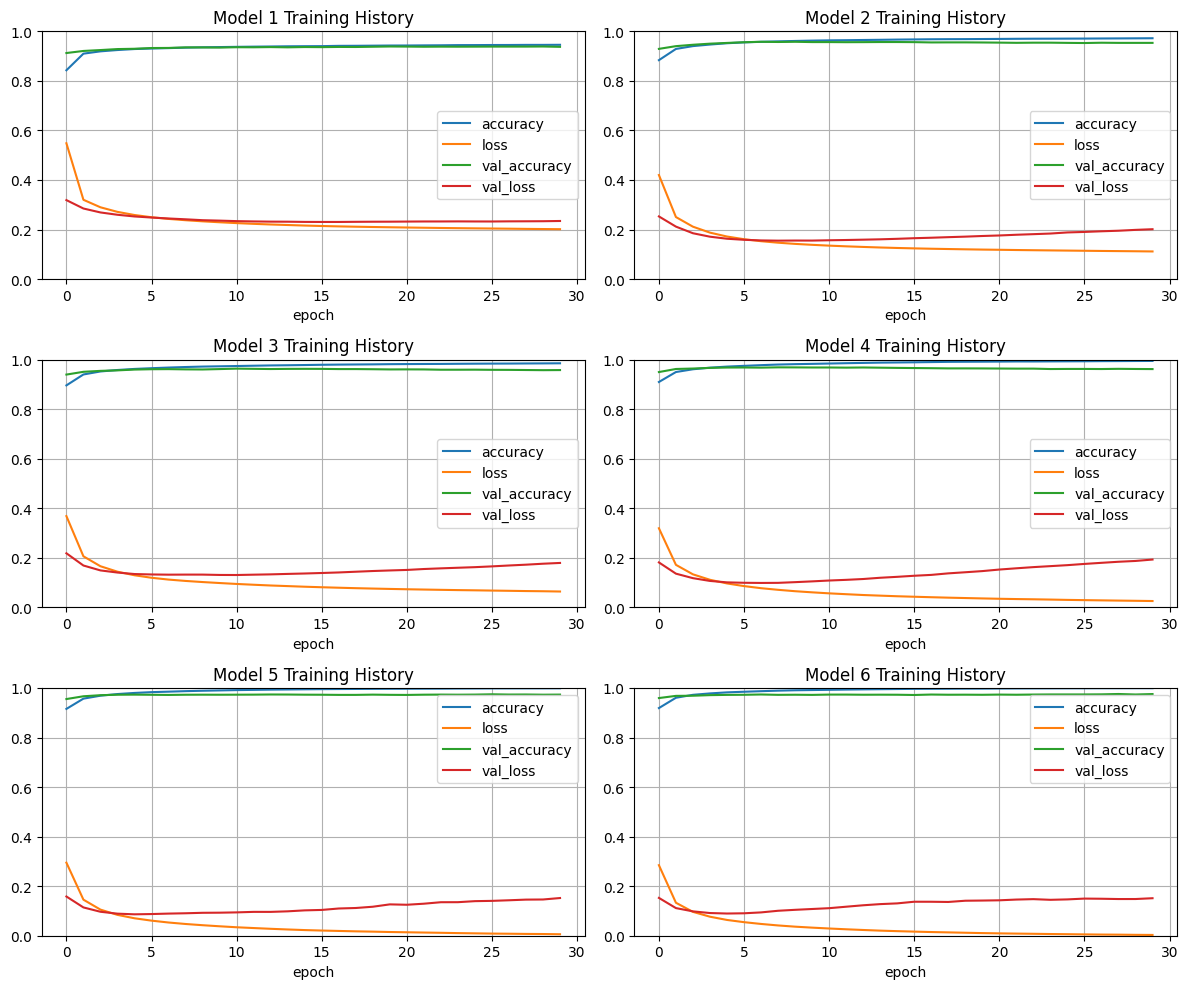

In [ ]:
# view behavior over epochs for each model
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 grid to easily iterate

for i, fit_results in enumerate(fit_results_list):
  pd.DataFrame(fit_results.history).plot(ax=axes[i])
  axes[i].set_title(f"Model {i+1} Training History")
  axes[i].grid(True)
  axes[i].set_ylim(0, 1) # set the vertical range to [0-1]
  axes[i].set_xlabel("epoch") # set the vertical range to [0-1]

plt.tight_layout()
plt.show()

----------------------------------
Model 0 Confusion Matrix


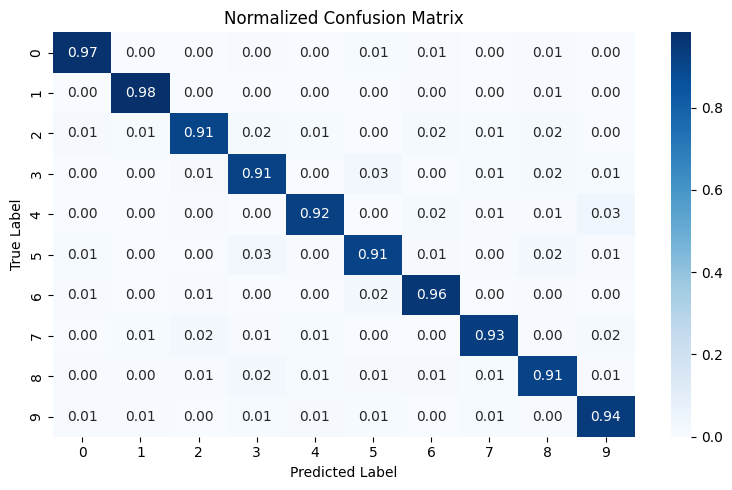

----------------------------------
Model 1 Confusion Matrix


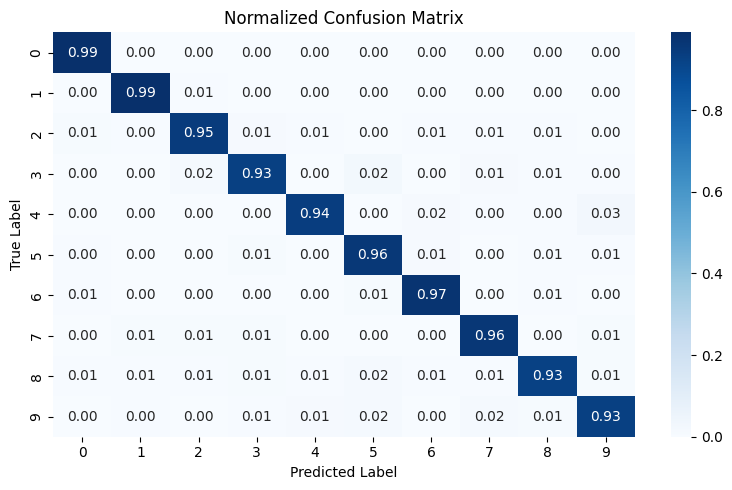

----------------------------------
Model 2 Confusion Matrix


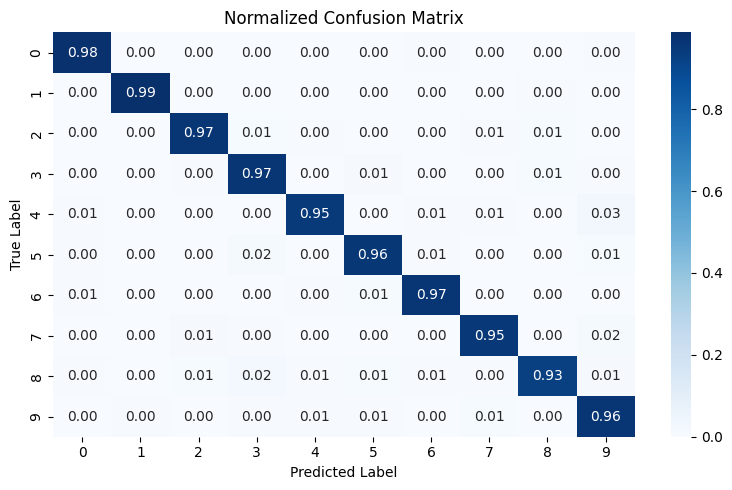

----------------------------------
Model 3 Confusion Matrix


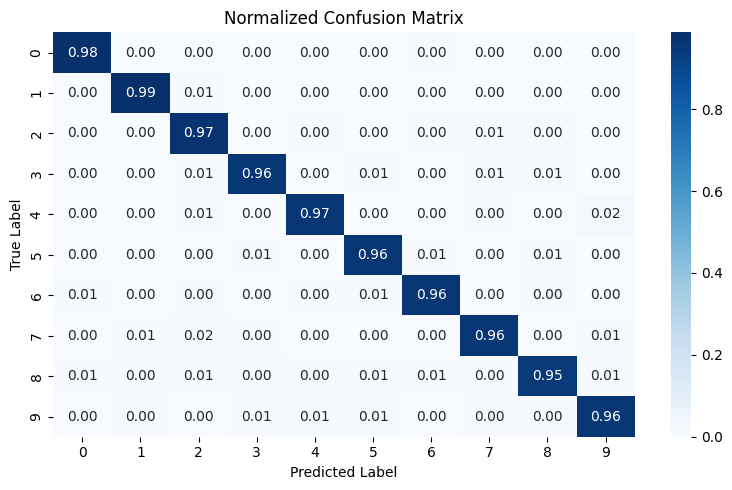

----------------------------------
Model 4 Confusion Matrix


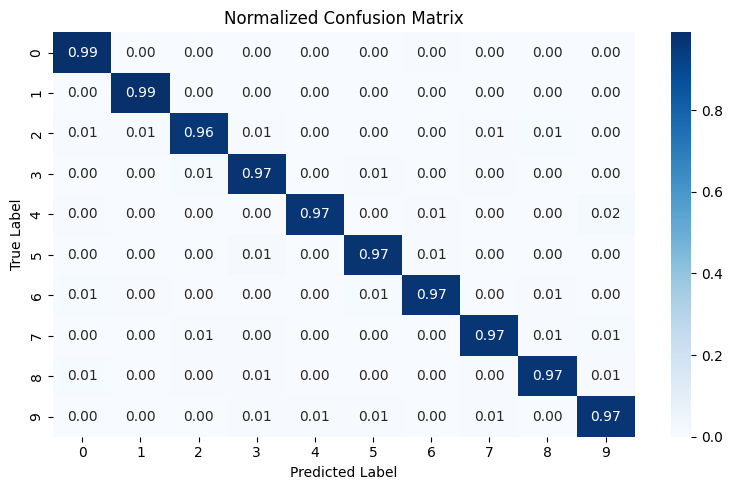

----------------------------------
Model 5 Confusion Matrix


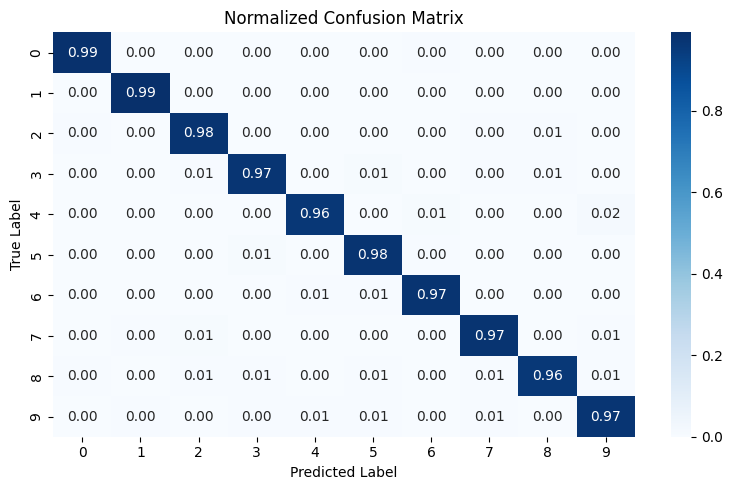

In [ ]:
# Iterate through our models to print confusion matrix metrics
for index, predictions in enumerate(predictions_list):
  argmax_predictions = np.argmax(predictions,
                               axis=1
                              )
  print("----------------------------------")
  print(f"Model {index} Confusion Matrix")
  cm = confusion_matrix(test_labels, argmax_predictions)
  return_confusion_matrix(cm)

In [ ]:
# The best model (most accuract) had the most nodes
best_model_node_count = 100

# Experiment 4
Use PCA decomposition to reduce the number of dimensions of our training set of 28x28 dimensional MNIST images from 784 to 154 (with 95% of training images variance lying along these components). We also reduce the number of dimensions of 'best' model from Experiment 3 to 154 inputs nodes and train it on the new lower dimensional data

In [ ]:
# To get consistint results each time we rerun the code.
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Reducing dimensionality
pca = PCA(n_components=0.95)
train_images_red = pca.fit_transform(train_images)
test_images_red = pca.transform(test_images)
val_images_red = pca.transform(val_images)

In [ ]:
test_images_red.shape, train_images_red.shape, val_images_red.shape

((10000, 154), (55000, 154), (5000, 154))

In [ ]:
# Using node count from the best model from experiment 3
model = models.Sequential()
model.add(layers.Dense(best_model_node_count, activation='relu', input_shape=(154,)))
model.add(layers.Dense(10, activation='softmax'))

# For use with non-categorical labels
model.compile(optimizer='rmsprop',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
history = model.fit(train_images_red, train_labels, epochs=30,validation_data=(val_images_red, val_labels))

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8350 - loss: 0.6147 - val_accuracy: 0.9548 - val_loss: 0.1562
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9588 - loss: 0.1430 - val_accuracy: 0.9682 - val_loss: 0.1126
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9725 - loss: 0.0964 - val_accuracy: 0.9726 - val_loss: 0.0953
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9807 - loss: 0.0720 - val_accuracy: 0.9730 - val_loss: 0.0868
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9851 - loss: 0.0569 - val_accuracy: 0.9746 - val_loss: 0.0831
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9881 - loss: 0.0460 - val_accuracy: 0.9762 - val_loss: 0.0821
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9906 - loss: 0.0379 - val_accuracy: 0.9768 - val_loss: 0.0832
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9923 - loss: 0.0316 - val_accurac

In [ ]:
hist_dict = history.history
hist_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
print(f'''acc: {hist_dict['accuracy'][-1]:.4}, val acc: {hist_dict['val_accuracy'][-1]:.4},
loss: {hist_dict['loss'][-1]:.4}, val loss: {hist_dict['val_loss'][-1]:.4}''')

acc: 0.9999, val acc: 0.975,
loss: 0.0006603, val loss: 0.171


In [ ]:
test_loss, test_acc = model.evaluate(test_images_red, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9681 - loss: 0.1888


In [ ]:
print(f'test acc: {test_acc}, test loss: {test_loss}')

test acc: 0.9746999740600586, test loss: 0.15359514951705933


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

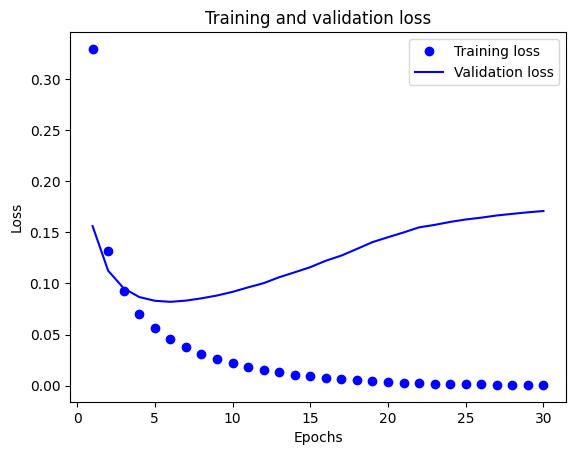

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

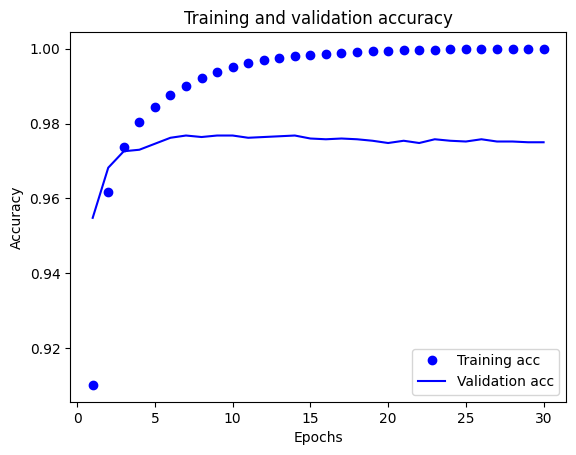

In [ ]:
plt.clf()   # clear figure
acc_values = history_dict['accuracy']
# val_acc_values = history_dict['val_acc']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Experiment 5
We use a Random Forest classifier to get the relative importance of the 784 features (pixels) of the 28x28 dimensional images in training set of MNIST images and select the top 70 features (pixels). We train our 'best' dense neural network using these 70 features and compare its performance to the the dense neural network models from EXPERIMENTS 3 and 4.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(train_images,train_labels)

RandomForestClassifier(random_state=42)

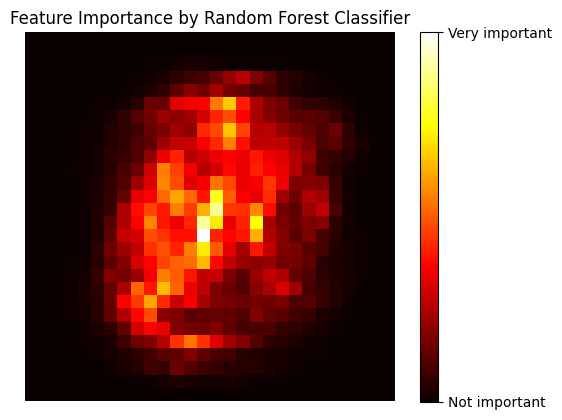

In [ ]:
# https://github.com/ageron/handson-ml2/blob/master/07_ensemble_learning_and_random_forests.ipynb
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.hot,
               interpolation="nearest")
    plt.axis("off")

plot_digit(rnd_clf.feature_importances_)

cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(), rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'])

# plt.savefig("mnist_feature_importance_plot")
plt.title("Feature Importance by Random Forest Classifier")
plt.show()


In [ ]:
n = 70
imp_arr = rnd_clf.feature_importances_
idx = (-imp_arr).argsort()[:n]          # get the indices of the 70 "most important" features/pixels
len(idx)

70

In [ ]:
# Create training, validation and test images using just the 70 pixel locations obtained above
train_images_sm = train_images[:,idx]
test_images_sm = test_images[:,idx]
val_images_sm = val_images[:,idx]
train_images_sm.shape, test_images_sm.shape # the reduced images have dimension 70

((55000, 70), (10000, 70))

Text(0.5, 1.0, 'Selected Pixels Overlay, Digit 3')

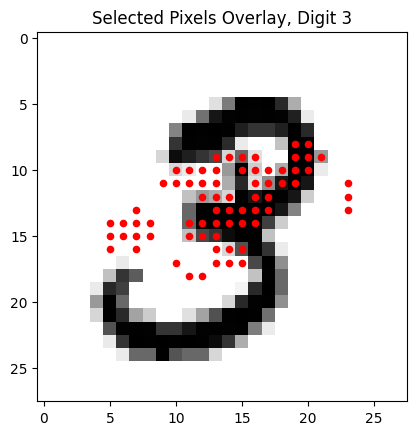

In [ ]:
# Visualizing the pixels
# to convert an index n, 0<= n < 784
def pair(n,size):
    x = n//size
    y = n%size
    return x,y

plt.imshow(train_images[1].reshape(28,28),cmap='binary')
x, y = np.array([pair(k,28) for k in idx]).T
plt.scatter(x,y,color='red',s=20)
plt.title("Selected Pixels Overlay, Digit 3")

Text(0.5, 1.0, 'Selected Pixels Overlay, Digit 8')

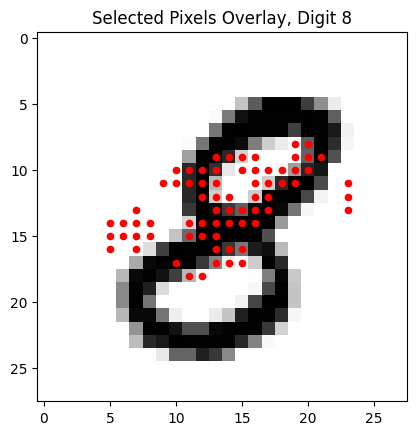

In [ ]:
# Visualizing the pixels
# to convert an index n, 0<= n < 784
def pair(n,size):
    x = n//size
    y = n%size
    return x,y

plt.imshow(train_images[5].reshape(28,28),cmap='binary')
x, y = np.array([pair(k,28) for k in idx]).T
plt.scatter(x,y,color='red',s=20)
plt.title("Selected Pixels Overlay, Digit 8")

In [ ]:
# Now, using our reduced dimensions and node count from the best model
model = models.Sequential()
model.add(layers.Dense(best_model_node_count, activation='relu', input_shape=(70,)))
model.add(layers.Dense(10, activation='softmax'))

# For use with non-categorical labels
model.compile(optimizer='rmsprop',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
history = model.fit(train_images_sm, train_labels, epochs=30,validation_data=(val_images_sm, val_labels))

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7515 - loss: 0.8275 - val_accuracy: 0.8792 - val_loss: 0.4286
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8705 - loss: 0.4310 - val_accuracy: 0.9016 - val_loss: 0.3450
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8952 - loss: 0.3497 - val_accuracy: 0.9146 - val_loss: 0.2998
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9082 - loss: 0.3026 - val_accuracy: 0.9206 - val_loss: 0.2744
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9164 - loss: 0.2732 - val_accuracy: 0.9244 - val_loss: 0.2597
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9217 - loss: 0.2533 - val_accuracy: 0.9264 - val_loss: 0.2495
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9259 - loss: 0.2391 - val_accuracy: 0.9272 - val_loss: 0.2435
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9294 - loss: 0.2280 - val_accurac

In [ ]:
hist_dict = history.history
hist_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
print(f'''acc: {hist_dict['accuracy'][-1]:.4}, val acc: {hist_dict['val_accuracy'][-1]:.4},
loss: {hist_dict['loss'][-1]:.4}, val loss: {hist_dict['val_loss'][-1]:.4}''')

acc: 0.953, val acc: 0.938,
loss: 0.1648, val loss: 0.2447


In [ ]:
test_loss, test_acc = model.evaluate(test_images_sm, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9196 - loss: 0.2887


In [ ]:
print(f'test acc: {test_acc}, test loss: {test_loss}')

test acc: 0.9362000226974487, test loss: 0.22966958582401276


In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

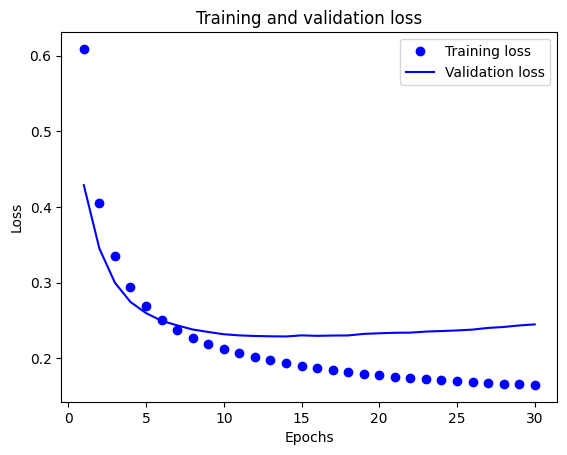

In [ ]:
# compare our models

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


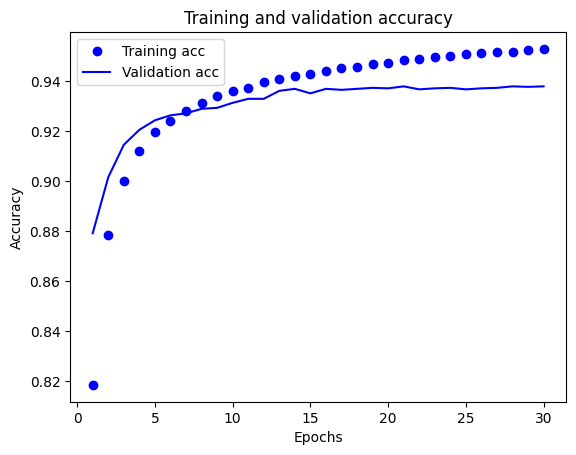

In [ ]:
plt.clf()   # clear figure
acc_values = history_dict['accuracy']
# val_acc_values = history_dict['val_acc']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
